## Geocalibration ZL048 and ZR048

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R
from scipy.optimize import minimize
import plotly.express as px
from plotly.subplots import make_subplots
from typing import List

In [2]:
to_vec_comma = lambda x: np.array([float(i) for i in x[1:-1].split(",")])
to_vec_space = lambda x: np.array([float(i.strip()) for i in x[1:-1].split(" ") if len(i)])
to_mat = lambda x: np.array([[float(val.strip()) for val in r[1:-1].split(" ") if len(val)] for r in x[1:-1].split("\n ")])

def get_zl_zr(f_str:str, data:pd.DataFrame):
    """
    Extract the data for focus [f_str] for ZL and ZR cameras
    f_str: str, string of the focus number
    data: pd.DataFrame, the data
    """
    d_left = data[data["cam"]==f"ZL{f_str}"].copy().reset_index(drop=True)
    d_right = data[data["cam"]==f"ZR{f_str}"].copy().reset_index(drop=True)
    return d_left, d_right

def parse_cahvor(z_data:pd.DataFrame):
  """
  return the data with the cahvor parameters parsed
  """
  z_data["c_r_vec"] = z_data["c_r_est"].apply(to_vec_space)
  z_data["h_r_vec"] = z_data["h_r_est"].apply(to_vec_space)
  z_data["v_r_vec"] = z_data["v_r_est"].apply(to_vec_space)
  z_data["a_r_vec"] = z_data["a_r_est"].apply(to_vec_space)
  z_data["R_rpm_mat"] = z_data["R_rpm"].apply(to_mat)
  z_data["t_rpm_vec"] = z_data["t_rpm"].apply(to_vec_comma)

def get_fl(idx:int, data_:np.ndarray,
           left_fl0:float, left_fl1:float,
           right_fl0:float, right_fl1:float)->float:
  """
  Calculates the focal length using above linear model
  """
  fmc = data_["fmc"][idx]
  if (data_["cam"][idx][1] == "L"):
    return left_fl0 + left_fl1 * fmc
  elif (data_["cam"][idx][1] == "R"):
    return right_fl0 + right_fl1 * fmc

def get_R_rpm(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Rotation matrix going from r_prime frame to mast frame
  """
  R_rpm = data_["R_rpm_mat"][idx]
  return R_rpm

def get_KC(idx:int, data_:np.ndarray,
           left_fl0:float, left_fl1:float,
           right_fl0:float, right_fl1:float)->np.ndarray:
  """
  Forms the Kc matrix for that idx
  """
  b1, b2, cx, cy = data_["b1_est"][idx], data_["b2_est"][idx], data_["cx_est"][idx], data_["cy_est"][idx]
  fl = get_fl(idx, data_, left_fl0, left_fl1, right_fl0, right_fl1)
  Kc = np.array([[fl+b1, b2, cx],
               [0, fl, cy],
               [0, 0, 1]])
  return Kc

def get_KC_inv(idx:int, data_:np.ndarray,
          left_fl0:float, left_fl1:float,
          right_fl0:float, right_fl1:float)->np.ndarray:
  b1, b2, cx, cy = data_["b1_est"][idx], data_["b2_est"][idx], data_["cx_est"][idx], data_["cy_est"][idx]
  fl = get_fl(idx, data_, left_fl0, left_fl1, right_fl0, right_fl1)
  kc_inv = np.array([[1/(fl+b1), -b2/(fl*(fl+b1)), ((cy*b2)/(fl*(fl+b1)) - cx/(fl+b1))],
                     [0, 1/fl, -cy/fl],
                     [0, 0, 1]])
  return kc_inv

def get_H_r_data(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Form the H matrix from the ground truth data
  """
  h_i = np.expand_dims(data_["h_r_vec"][idx], axis=1)
  v_i = np.expand_dims(data_["v_r_vec"][idx], axis=1)
  a_i = np.expand_dims(data_["a_r_vec"][idx], axis=1)
  H_i = np.concatenate([h_i, v_i, a_i], axis=1)

  return H_i


In [3]:
f_str = "048"

data_fpath = "data/m41_site_cal_v229_v4.xlsx"
data_all = pd.read_excel(data_fpath)
outlier_removed = False

# parse data into left and right cam
zl, zr = get_zl_zr(f_str, data_all)

# parse cahvor vectors
parse_cahvor(zl)
parse_cahvor(zr)

print(f"Number of data points for zl{f_str}:\t{zl.shape[0]}")
print(f"Number of data points for zr{f_str}:\t{zr.shape[0]}")

Number of data points for zl048:	38
Number of data points for zr048:	248


Below we identify the outliers based on the Focal Length to FMC plots

In [4]:
zl_outlier_idx = [5,6,7,8,9,10,11,21,22,23,24,25,26,27,28,29,32,33,34,35,36,37]
zr_outlier_idx = []

zl_outliers = zl.iloc[zl_outlier_idx,:]
zr_outliers = zr.iloc[zr_outlier_idx,:]

fig = make_subplots(rows=1, cols=2, subplot_titles=["ZL048", "ZR048"])

# focal length - fmc plot for ZL048
left_scatter_all = px.scatter(zl, x="fmc", y="f_est", hover_data=[zl.index])
left_scatter_outliers = px.scatter(zl_outliers, x="fmc", y="f_est", hover_data=[zl_outliers.index])
left_scatter_outliers.update_traces(marker=dict(color="red"))
fig.add_trace(left_scatter_all.data[0], row=1, col=1)
fig.add_trace(left_scatter_outliers.data[0], row=1, col=1)

# focal lenth - fmc plot for ZR048
right_scatter_all = px.scatter(zr, x="fmc", y="f_est", hover_data=[zr.index])
right_scatter_outliers = px.scatter(zr_outliers, x="fmc", y="f_est", hover_data=[zr_outliers.index])
right_scatter_outliers.update_traces(marker=dict(color="red"))
fig.add_trace(right_scatter_all.data[0], row=1, col=2)
fig.add_trace(right_scatter_outliers.data[0], row=1, col=2)


fig.update_layout(width=1000, height=400, title="f_est vs fmc for ZL048 and ZR048")

In [5]:
if not outlier_removed:
  zl = zl.drop(zl_outlier_idx).reset_index(drop=True)
  zr = zr.drop(zr_outlier_idx).reset_index(drop=True)
  
  outlier_removed = True
  
print('-'*75)
print(f"Number of data points for zl{f_str}:\t{zl.shape[0]}")
print(f"Number of data points for zr{f_str}:\t{zr.shape[0]}")

---------------------------------------------------------------------------
Number of data points for zl048:	16
Number of data points for zr048:	248


Linear least squares fit

Left:  f_est = 6664.2423 + 0.0011 * fmc
left res square error: 5.6034
---------------------------------------------------------------------------
Right: f_est = 6589.6131 + 0.0342 * fmc
right res square error: 10.6554


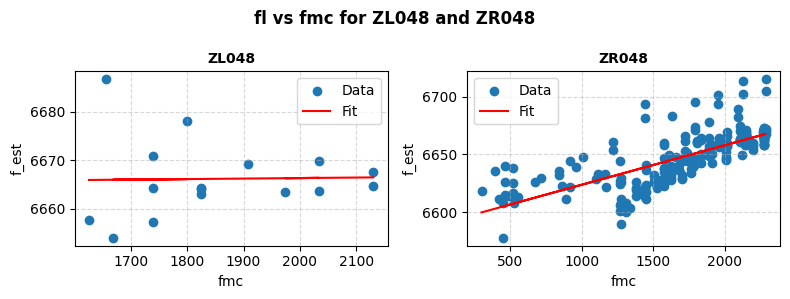

In [6]:
# Linear least squares fit for fl vs fmc
X_l =  np.vstack([np.ones(zl["fmc"].shape[0]), zl["fmc"]]).T
X_r =  np.vstack([np.ones(zr["fmc"].shape[0]), zr["fmc"]]).T

fl_l_0, fl_l_1  = np.linalg.inv(X_l.T @ X_l) @ X_l.T @ zl["f_est"]
res_l = (np.abs(zl["f_est"] - (fl_l_0 + fl_l_1 * zl["fmc"]))).mean()
fl_r_0, fl_r_1 = np.linalg.inv(X_r.T @ X_r) @ X_r.T @ zr["f_est"]
res_r = (np.abs(zr["f_est"] - (fl_r_0 + fl_r_1 * zr["fmc"]))).mean()

print(f"Left:  f_est = {fl_l_0:.4f} + {fl_l_1:.4f} * fmc")
print(f"left res square error: {res_l:.4f}")
print('-'*75)
print(f"Right: f_est = {fl_r_0:.4f} + {fl_r_1:.4f} * fmc")
print(f"right res square error: {res_r:.4f}")

# plot the fit
fig, ax = plt.subplots(1, 2, figsize=(8, 3))
for i, (d, fl_0, fl_1) in enumerate(zip([zl, zr], [fl_l_0, fl_r_0], [fl_l_1, fl_r_1])):
    ax[i].scatter(d["fmc"], d["f_est"], label="Data")
    ax[i].plot(d["fmc"], fl_0 + fl_1 * d["fmc"], label="Fit", color="red")
    ax[i].set_xlabel("fmc")
    ax[i].set_ylabel("f_est")
    ax[i].set_title(f"ZL{f_str}" if i==0 else f"ZR{f_str}",
                    fontweight="bold", fontsize=10)
    ax[i].legend()
    ax[i].grid(linestyle="--", alpha=0.5)

fig.suptitle(f"fl vs fmc for ZL{f_str} and ZR{f_str}", fontweight="bold", fontsize=12)
fig.tight_layout()

## Rotation Fitting

Here we assume the value of the rotation $R^r_{r'}$ from the fit given by ZL034 and ZR034 and we seek to find the rotation $R^m_c$. From the transformaitons we have

$$R^m_c = (R^r_{r'} R^{r'}_m)^T H^r (H^c)^{-1}$$

Let the quaternion related to the $R^m_c$ be $q^m_c$ and let the quaternion calculated from data be $q^m_{c,data}$. Then we seek to find $q^m_{c,model}$ that solves the following

$$ \min_{q^m_{c,model}} \sum_i \arccos(2 \langle q^m_{c,i,model}, q^m_{c,i,data} \rangle^2 -1) $$

In [7]:
def dist_q(q1:np.ndarray, q2:np.ndarray)->float:
  assert q1.shape == (4,)
  assert q2.shape == (4,)

  q1 = q1 / np.linalg.norm(q1)
  q2 = q2 / np.linalg.norm(q2)
  
  return np.arccos(2 * (np.dot(q1, q2)**2) - 1)

def gen_rot_obj(data_:pd.DataFrame)->callable:
  data__ = data_.copy()
  q_rrp = [5.51277082e-05, 3.46611661e-04, -7.85697625e-04, -9.99999630e-01]

  def rot_obj(x_:List):
  
    assert len(x_) == 8

    total_cost = 0
    count = 0
    for i in range(data__.shape[0]):
      # calc rotation from model
      f = data__["fmc"][i]
      rot_mc_0 = R.from_quat(x_[:4])
      rot_mc_1 = R.from_quat(x_[4:8])
      rot_mc_model = rot_mc_0 * (rot_mc_1 ** (f/1000))
      q_mc_model = rot_mc_model.as_quat(canonical=True)

      # calc rotation from data
      fl = data__["f_est"][i]
      b1,b2 = data__["b1_est"][i], data__["b2_est"][i]
      cx, cy = data__["cx_est"][i], data_["cy_est"][i]
      Hc_inv =  np.array([[1/(fl+b1), 0, 0],
              [-b2/(fl*(fl+b1)),1/fl,0],
              [((cy*b2)/(fl*(fl+b1)))-(cx/(fl+b1)),-cy/fl,1]])

      rot_rrp = R.from_quat(q_rrp)
      rot_rpm = R.from_matrix(data__["R_rpm_mat"][i])
      Hr = get_H_r_data(i, data__)

      rot_mc_data = (rot_rrp * rot_rpm).as_matrix().T @ Hr @ Hc_inv
      q_mc_data = R.from_matrix(rot_mc_data).as_quat(canonical=True)

      # calc and add to total cost
      total_cost += dist_q(q_mc_data, q_mc_model)
      count += 1

    
    return (total_cost/count)
  
  return rot_obj


# left optimization
left_rot_obj = gen_rot_obj(zl)
x0_left = [0.44, 0.56, 0.50, 0.491, 0.01, 0.01, 0.01, 1]
left_res = minimize(left_rot_obj, x0_left, method="BFGS", 
               options={"gtol":1e-20, "xrtol":1e-20,"maxiter":200})
q_cm_zl_0 = np.array(left_res.x[0:4])/np.linalg.norm(left_res.x[0:4])
q_cm_zl_1 = np.array(left_res.x[4:8])

print(f"Left optimization")
print(f"Final function value:\t{left_res.fun:.6f}")
print(f"Final Jacobian value:\t{np.linalg.norm(left_res.jac):.6f}")
print(f"q_cm_zl_0:\t\t{q_cm_zl_0}")
print(f"q_cm_zl_1:\t\t{q_cm_zl_1}")
print('-'*100)


# right optimization
right_rot_obj = gen_rot_obj(zr)
x0_right = [0.4785, 0.467, 0.530, 0.5215, 0.01, 0.01, 0.01, 1]
right_res = minimize(right_rot_obj, x0_right, method="BFGS", 
               options={"gtol":1e-20, "xrtol":1e-20,"maxiter":200})
q_cm_zr_0 = np.array(right_res.x[0:4])/np.linalg.norm(right_res.x[0:4])
q_cm_zr_1 = np.array(right_res.x[4:8])

print(f"Right optimization")
print(f"Final function value:\t{right_res.fun:.6f}")
print(f"Final Jacobian value:\t{np.linalg.norm(right_res.jac):.6f}")
print(f"q_cm_zl_0:\t\t{q_cm_zr_0}")
print(f"q_cm_zl_1:\t\t{q_cm_zr_1}")
print('-'*100)


Left optimization
Final function value:	0.001172
Final Jacobian value:	0.001921
q_cm_zl_0:		[0.44377992 0.5625695  0.49968724 0.48671101]
q_cm_zl_1:		[-2.32039184e-03 -7.76827219e-04 -1.64998431e-03  9.99950642e-01]
----------------------------------------------------------------------------------------------------
Right optimization
Final function value:	0.001736
Final Jacobian value:	0.000296
q_cm_zl_0:		[0.47836347 0.46744645 0.53026443 0.5210392 ]
q_cm_zl_1:		[-2.41929644e-04 -7.25081136e-05 -1.41122889e-04  1.00542224e+00]
----------------------------------------------------------------------------------------------------


In [73]:
def plot_Hr(q_cm_0:np.ndarray, q_cm_1:np.ndarray, data_:pd.DataFrame, f_str:str):
  Hr_data = []
  Hr_model = []
  q_rrp = [3.02010699e-04, -1.49266848e-03, -7.92022859e-03, 9.58993160e-01]

  for i in range(data_.shape[0]):
    # data
    Hr_data.append(get_H_r_data(i, data_))

    # model
    rot_rrp = R.from_quat(q_rrp)
    rot_rpm = R.from_matrix(get_R_rpm(i, data_))
    
    fl = data_["f_est"][i]
    b1,b2 = data_["b1_est"][i], data_["b2_est"][i]
    cx, cy = data_["cx_est"][i], data_["cy_est"][i]

    Hc = np.array([[fl+b1, b2, cx],
                [0,fl,cy],
                [0,0,1]]).T

    f = data_["fmc"][i]
    rot_mc_0 = R.from_quat(q_cm_0)
    rot_mc_1 = R.from_quat(q_cm_1)
    rot_mc = rot_mc_0 * (rot_mc_1**(f/1000))
    rot_rc = rot_rrp * rot_rpm * rot_mc

    Hr_model.append(rot_rc.as_matrix() @ Hc)

  # plot
  fig, ax = plt.subplots(3, 3, figsize=(12,8))

  for r in range(3):
    for c in range(3):

      ax[r,c].scatter(data_["fmc"], [H[r,c] for H in Hr_data], label="expectation")
      ax[r,c].scatter(data_["fmc"], [H[r, c] for H in Hr_model], color="red", marker='x', label="model")
      ax[r,c].set_title(f"$H^r$[{r},{c}]")
      ax[r,c].set_xlabel("fmc")
      ax[r,c].set_ylabel(f"$H^r$[{r},{c}]")
      ax[r,c].grid(linestyle="--", alpha=0.5)

  ax[0,2].legend(["$H^r$", "$(R^r_{rp} R^{rp}_M R^M_C) H^c$"], bbox_to_anchor=(1.6,1))

  fig.suptitle(f"$H^r$ {f_str}", fontweight="bold", fontsize=12)
  fig.tight_layout()
  
  return fig, ax

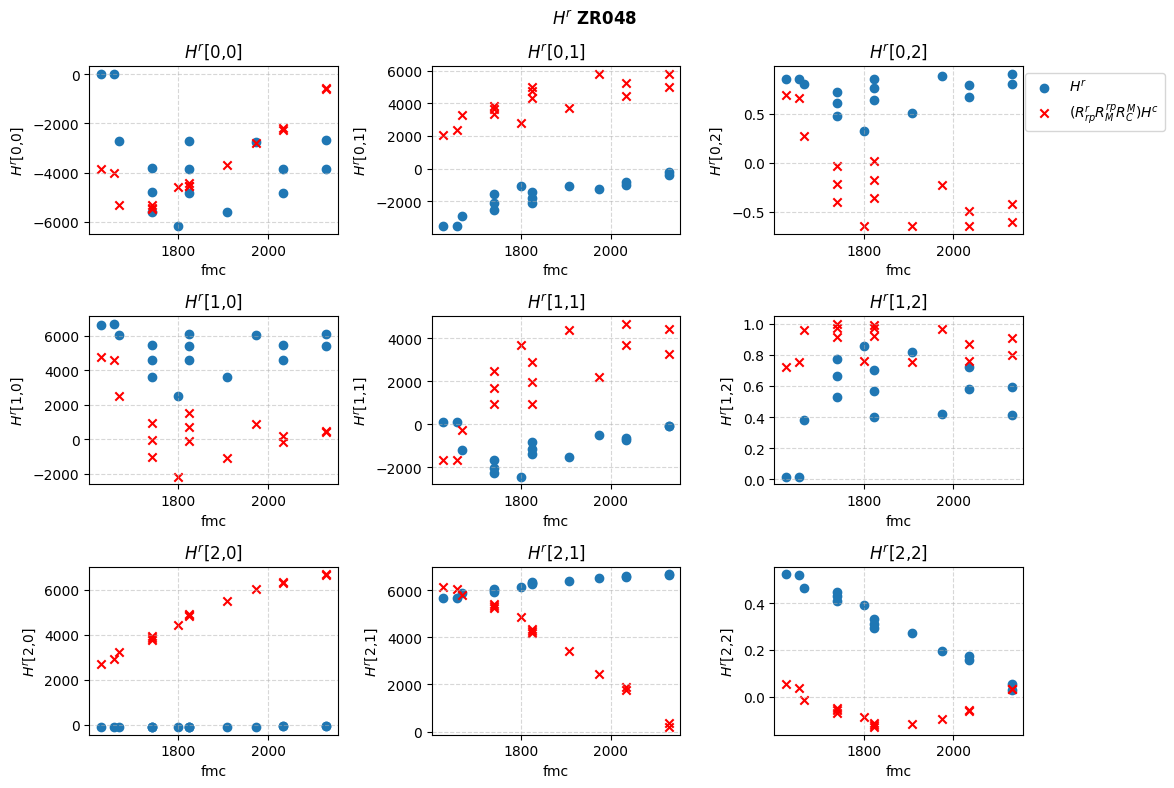

In [74]:
fig, ax = plot_Hr(q_cm_zl_0, q_cm_zl_1, zl, f_str)


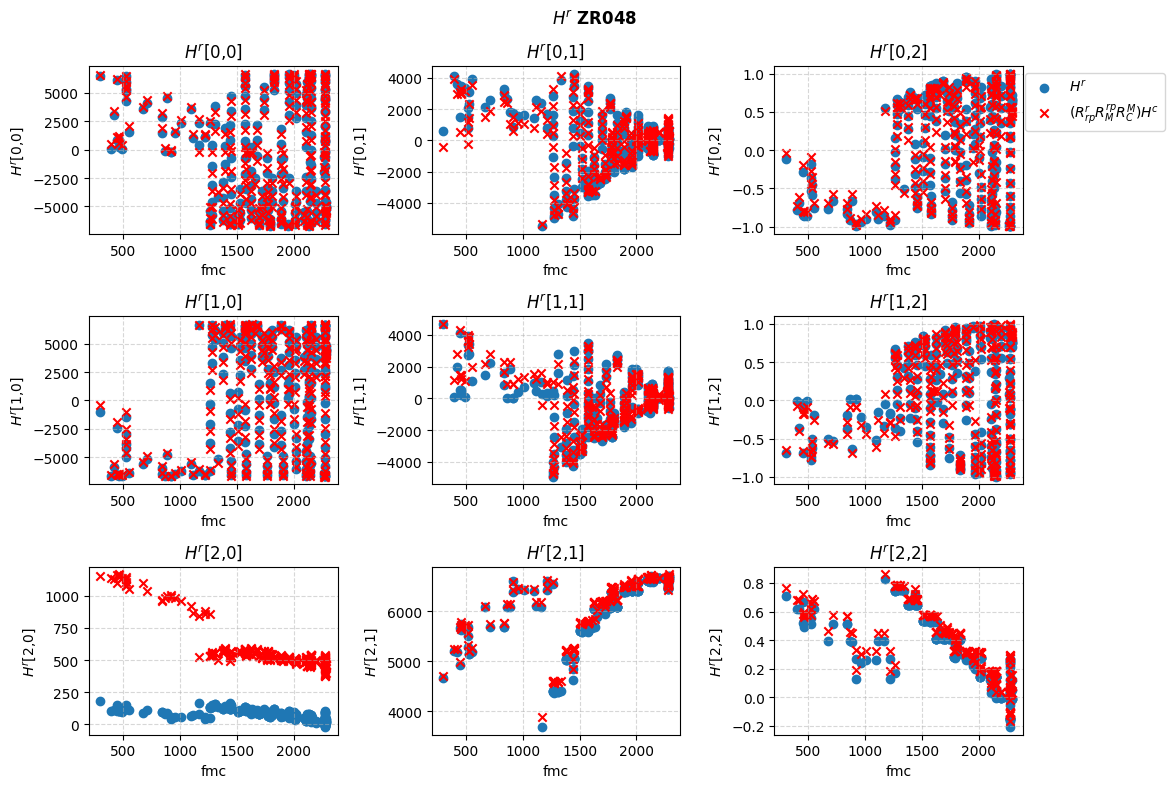

In [75]:
fig, ax = plot_Hr(q_cm_zr_0, q_cm_zr_1, zr, "ZR048")

In [79]:
def plot_q_mc(q_mc_0:np.ndarray, q_mc_1:np.ndarray, data_:pd.DataFrame, f_str:str):
  q_mc_model = []
  q_mc_data = []
  delta_dist = []
  delta_angle = []
  q_rrp = [3.02010699e-04, -1.49266848e-03, -7.92022859e-03, 9.58993160e-01]

  for i in range(data_.shape[0]):
    # q_mc from data
    R_rrp = R.from_quat(q_rrp).as_matrix()
    R_rpm = get_R_rpm(i, data_)
    Hr = get_H_r_data(i, data_)
    
    fl = data_["f_est"][i] 
    b1,b2 = data_["b1_est"][i], data_["b2_est"][i]
    cx, cy = data_["cx_est"][i], data_["cy_est"][i]

    Hc = np.array([[fl+b1, b2, cx],
                [0,fl,cy],
                [0,0,1]]).T

    R_mc_data = (R_rrp @ R_rpm).T @ Hr @ np.linalg.inv(Hc)
    q_mc_data_ = R.from_matrix(R_mc_data).as_quat(canonical=True)
    q_mc_data.append(q_mc_data_)

    # q_mc from model
    rot_mc_0 = R.from_quat(q_mc_0)
    rot_mc_1 = R.from_quat(q_mc_1)
    f = data_["fmc"][i]
    rot_mc = rot_mc_0 * (rot_mc_1**(f/1000))
    q_mc_model_ = rot_mc.as_quat(canonical=True)
    q_mc_model.append(q_mc_model_)

    delta_dist.append(dist_q(q_mc_data_, q_mc_model_))
    delta_rot = R.from_quat(q_mc_data_).inv() * R.from_quat(q_mc_model_)
    delta_angle.append(delta_rot.as_euler("xyz", degrees=True))

  # plot
  fig, ax = plt.subplots(2, 4, figsize=(12,5))

  for i in range(4):
    ax[0,i].scatter(data_["fmc"], [q[i] for q in q_mc_data], label="expectation")
    # ax[0,i].scatter(data_["fmc"], [q[i] for q in q_mc_model], color="red", marker='x', label="model")
    ax[0,i].set_title(f"$q_{i}$")
    ax[0,i].set_xlabel("fmc")
    ax[0,i].set_ylabel(f"$q_{i}$")
    ax[0,i].grid(linestyle="--", alpha=0.5)

  for i, angle in enumerate(["x", "y", "z"]):
    ax[1,i].scatter(data_["fmc"], [angle[i] for angle in delta_angle])
    ax[1,i].set_title(f"$\Theta_{angle}$")
    ax[1,i].set_xlabel("fmc")
    ax[1,i].set_ylabel(f"$\Theta_{angle}$")
    ax[1,i].grid(linestyle="--", alpha=0.5)
  
  ax[0,3].legend(["$q_{mc}$ data", "$q_{mc}$ model"], bbox_to_anchor=(1,1))

  ax[1,3].scatter(data_["fmc"], delta_dist)
  ax[1,3].set_title("Distance")
  ax[1,3].set_xlabel("fmc")
  ax[1,3].set_ylabel("Distance")
  ax[1,3].grid(linestyle="--", alpha=0.5)

  fig.suptitle(f"$q^m_c$ for {f_str}", fontsize=16, fontweight="bold")
  fig.tight_layout()

  return fig, ax


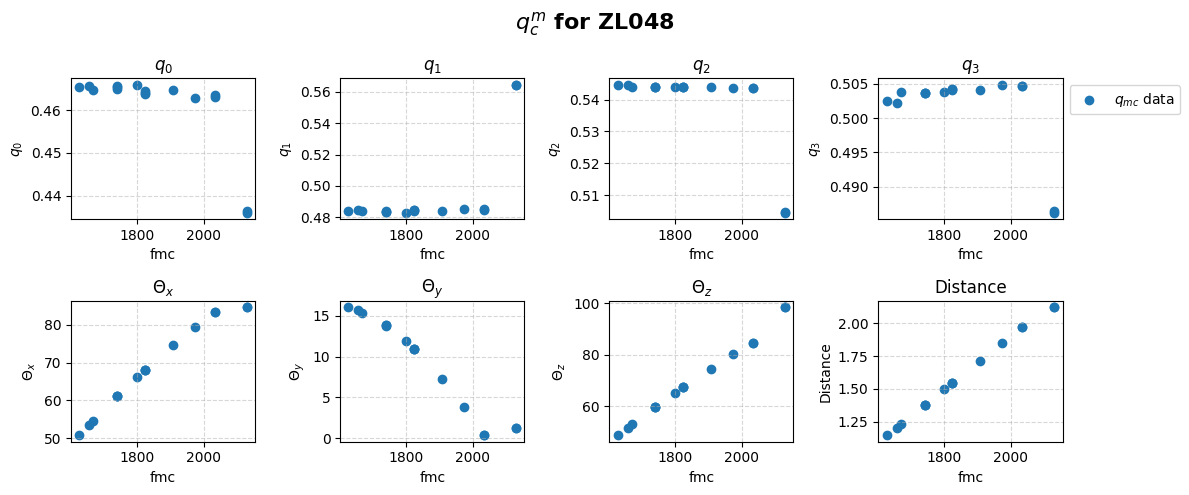

In [80]:
fig, ax = plot_q_mc(q_cm_zl_0, q_cm_zl_1, zl, "ZL048")

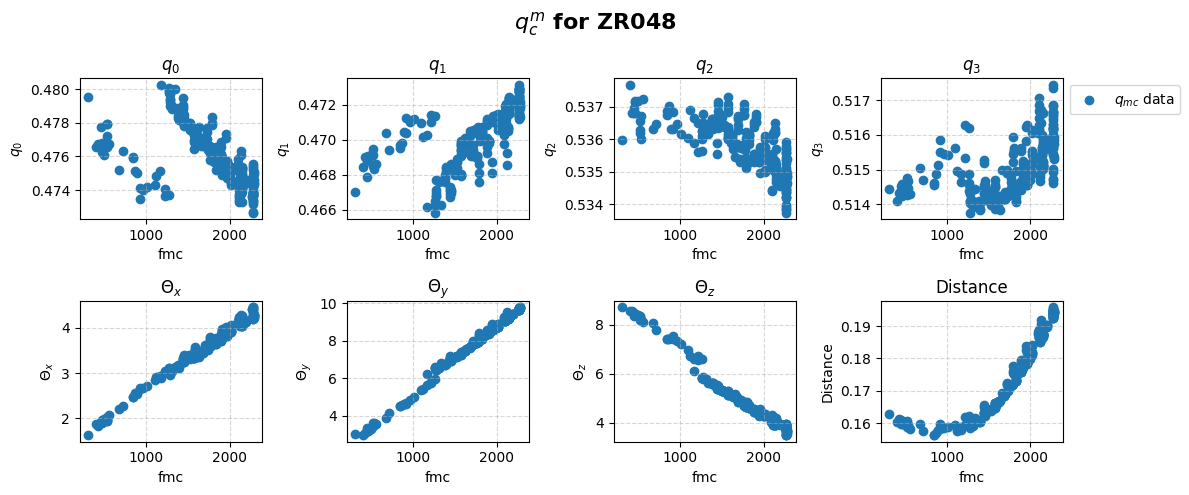

In [81]:
fig, ax = plot_q_mc(q_cm_zr_0, q_cm_zr_1, zr, "ZR048")

In [30]:
def plot_q_rc(data_:pd.DataFrame, f_str:str):
  q_rc_data = []
  euler_rc_data = []
  for i in range(data_.shape[0]):
    H_r = get_H_r_data(i, data_)
    fl = data_["f_est"][i]
    b1, b2 = data_["b1_est"][i], data_["b2_est"][i]
    cx, cy = data_["cx_est"][i], data_["cy_est"][i]
    Hc_inv =  np.array([[1/(fl+b1), 0, 0],
                [-b2/(fl*(fl+b1)),1/fl,0],
                [((cy*b2)/(fl*(fl+b1)))-(cx/(fl+b1)),-cy/fl,1]])
    
    R_rc = H_r @ Hc_inv
    q_rc_data.append(R.from_matrix(R_rc).as_quat(canonical=True))
    euler_rc_data.append(R.from_matrix(R_rc).as_euler("xyz", degrees=True))

  fig, ax = plt.subplots(2, 4, figsize=(10, 5))

  for i in range(4):
    ax[0,i].scatter(data_["fmc"], [q[i] for q in q_rc_data])
    ax[0,i].set_title(f"$q_{i}$")
    ax[0,i].set_xlabel("fmc")
    ax[0,i].set_ylabel(f"$q_{i}$")
    ax[0,i].grid(linestyle="--", alpha=0.5)

  for i, angle in enumerate(["x", "y", "z"]):
    ax[1,i].scatter(data_["fmc"], [angle[i] for angle in euler_rc_data])
    ax[1,i].set_title(f"$\Theta_{angle}$")
    ax[1,i].set_xlabel("fmc")
    ax[1,i].set_ylabel(f"$\Theta_{angle}$")
    ax[1,i].grid(linestyle="--", alpha=0.5)

  fig.suptitle(f"$q^r_c$ for {f_str}", fontsize=16, fontweight="bold")
  fig.tight_layout()  

  return fig, ax


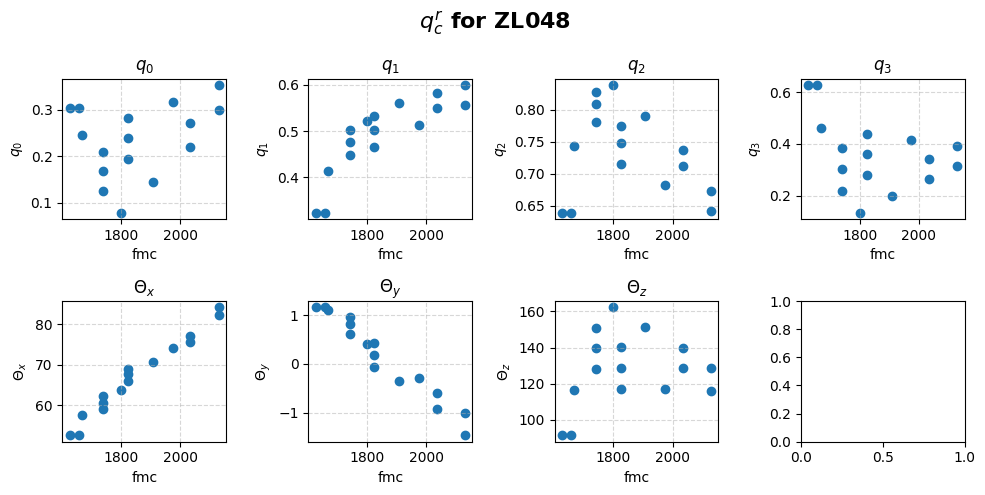

In [31]:
fig, ax = plot_q_rc(zl, "ZL048")

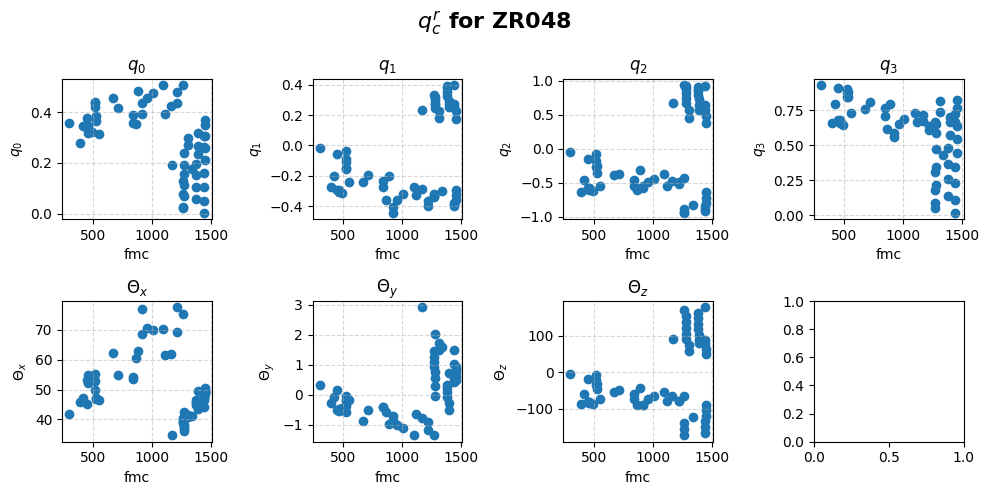

In [179]:
zr_filtered = zr[zr["fmc"] < 1500]
# zr_filtered = zr_filtered[zr_filtered["fmc"] < 2000]
zr_filtered = zr_filtered.reset_index(drop=True)

fig, ax = plot_q_rc(zr_filtered, "ZR048")

In [180]:
def dist_q(q1:np.ndarray, q2:np.ndarray)->float:
  assert q1.shape == (4,)
  assert q2.shape == (4,)

  q1 = q1 / np.linalg.norm(q1)
  q2 = q2 / np.linalg.norm(q2)
  
  return np.arccos(2 * (np.dot(q1, q2)**2) - 1)

def dist_R(R1:np.ndarray, R2:np.ndarray)->float:
  return np.linalg.norm(log(R1 @ R2.T))

def gen_rot_obj(data_:pd.DataFrame)->callable:
  data__ = data_.copy()
  q_rrp = [3.02010699e-04, -1.49266848e-03, -7.92022859e-03, 9.58993160e-0]

  def rot_obj(x_:List):
  
    assert len(x_) == 8

    total_cost = 0
    count = 0
    for i in range(data__.shape[0]):
      # calc rotation from model
      rot_rrp = R.from_quat(q_rrp)
      rot_rpm = R.from_matrix(data__["R_rpm_mat"][i])
      f = data__["fmc"][i]
      rot_mc_0 = R.from_quat(x_[0:4])
      rot_mc_1 = R.from_quat(x_[4:8])
      rot_rc_model = rot_rrp * rot_rpm * rot_mc_0 * (rot_mc_1 ** (f/1000))
      q_rc_model = R.from_matrix(rot_rc_model.as_matrix()).as_quat(canonical=True)

      # calc rotation from data
      fl = data__["f_est"][i]
      b1,b2 = data__["b1_est"][i], data__["b2_est"][i]
      cx, cy = data__["cx_est"][i], data_["cy_est"][i]
      Hc_inv =  np.array([[1/(fl+b1), 0, 0],
              [-b2/(fl*(fl+b1)),1/fl,0],
              [((cy*b2)/(fl*(fl+b1)))-(cx/(fl+b1)),-cy/fl,1]])
      Hr = get_H_r_data(i, data__)

      rot_rc_data = R.from_matrix(Hr @ Hc_inv)
      q_rc_data = rot_rc_data.as_quat(canonical=True)

      # calc and add to total cost
      total_cost += dist_q(q_rc_model, q_rc_data)
      count += 1

    
    return (total_cost/count)
  
  return rot_obj


# left optimization
left_rot_obj = gen_rot_obj(zl)
x0_left = [0.44, 0.56, 0.50, 0.491,
          0.01, 0.01, 0.01, 1]
left_res = minimize(left_rot_obj, x0_left, method="BFGS", 
               options={"gtol":1e-30, "xrtol":1e-30,"maxiter":200})
# q_rrp_zl = np.array(left_res.x[0:4])
q_mc_zl_0 = np.array(left_res.x[0:4])
q_mc_zl_1 = np.array(left_res.x[4:8])

print(f"Left optimization")
print(f"Final function value:\t{left_res.fun:.6f}")
print(f"Final Jacobian value:\t{np.linalg.norm(left_res.jac):.6f}")
# print(f"q_rrp:\t\t{q_rrp_zl}")
print(f"q_mc_zl_0:\t\t{q_mc_zl_0}")
print(f"q_mc_zl_1:\t\t{q_mc_zl_1}")
print('-'*100)


# right optimization
zr_filtered = zr[zr["fmc"] > 1500]
zr_filtered = zr_filtered[zr_filtered["fmc"] < 2000]
zr_filtered = zr_filtered.reset_index(drop=True)

right_rot_obj = gen_rot_obj(zr_filtered)
x0_right = [0.44, 0.56, 0.50, 0.491,
          0.01, 0.01, 0.01, 1]
right_res = minimize(right_rot_obj, x0_right, method="BFGS", 
               options={"gtol":1e-30, "xrtol":1e-30,"maxiter":200})
# q_rrp_zr = np.array(right_res.x[0:4])
q_mc_zr_0 = np.array(right_res.x[0:4])
q_mc_zr_1 = np.array(right_res.x[4:8])

print(f"Right optimization")
print(f"Final function value:\t{right_res.fun:.6f}")
print(f"Final Jacobian value:\t{np.linalg.norm(right_res.jac):.6f}")
# print(f"q_rrp:\t\t{q_rrp_zr}")
print(f"q_cm_zr_0:\t\t{q_mc_zr_0}")
print(f"q_cm_zr_1:\t\t{q_mc_zr_1}")
print('-'*100)

Left optimization
Final function value:	0.013054
Final Jacobian value:	0.112310
q_mc_zl_0:		[0.45399411 0.50167891 0.52764919 0.50776171]
q_mc_zl_1:		[ 1.31225766e-04 -9.47645493e-04  1.36740877e-02  9.93797591e-01]
----------------------------------------------------------------------------------------------------
Right optimization
Final function value:	0.035175
Final Jacobian value:	0.000083
q_cm_zr_0:		[0.46161919 0.48102314 0.51878681 0.52940658]
q_cm_zr_1:		[0.01503283 0.00895165 0.02187908 0.98300557]
----------------------------------------------------------------------------------------------------


In [189]:
def quat_to_rot(q:np.ndarray)->np.ndarray:
  # Extract the values from Q
    q0 = q[3]
    q1 = q[0]
    q2 = q[1]
    q3 = q[2]
     
    # First row of the rotation matrix
    r00 = 2 * (q0 * q0 + q1 * q1) - 1
    r01 = 2 * (q1 * q2 - q0 * q3)
    r02 = 2 * (q1 * q3 + q0 * q2)
     
    # Second row of the rotation matrix
    r10 = 2 * (q1 * q2 + q0 * q3)
    r11 = 2 * (q0 * q0 + q2 * q2) - 1
    r12 = 2 * (q2 * q3 - q0 * q1)
     
    # Third row of the rotation matrix
    r20 = 2 * (q1 * q3 - q0 * q2)
    r21 = 2 * (q2 * q3 + q0 * q1)
    r22 = 2 * (q0 * q0 + q3 * q3) - 1
     
    # 3x3 rotation matrix
    rot_matrix = np.array([[r00, r01, r02],
                           [r10, r11, r12],
                           [r20, r21, r22]])
    
    return rot_matrix


def plot_R_rc(q_mc_0:np.ndarray, q_mc_1:np.ndarray, data_:pd.DataFrame, f_str:str):
  R_rc_data = []
  R_rc_model = []

  for i in range(data_.shape[0]):
    # from data
    H_r = get_H_r_data(i, data_)
    fl = data_["f_est"][i]
    b1, b2 = data_["b1_est"][i], data_["b2_est"][i]
    cx, cy = data_["cx_est"][i], data_["cy_est"][i]
    Hc_inv =  np.array([[1/(fl+b1), 0, 0],
                [-b2/(fl*(fl+b1)),1/fl,0],
                [((cy*b2)/(fl*(fl+b1)))-(cx/(fl+b1)),-cy/fl,1]])
    
    R_rc = H_r @ Hc_inv
    R_rc_data.append(R.from_matrix(R_rc).as_matrix())

    # from model
    f = data_["fmc"][i]
    rot_mc_0 = R.from_quat(q_mc_0)
    rot_mc_1 = R.from_quat(q_mc_1)
    rot_mc_model = rot_mc_0 * (rot_mc_1 ** (f/1000))
    rot_rrp = R.from_quat([3.02010699e-04,-1.49266848e-03,-7.92022859e-03,9.58993160e-0])
    rot_rpm = R.from_matrix(get_R_rpm(i, data_))
    rot_rc_model = rot_rrp * rot_rpm * rot_mc_model

    R_rc_model.append(rot_rc_model.as_matrix())

  # plot
  fig, ax = plt.subplots(3, 3, figsize=(12,8))

  for r in range(3):
    for c in range(3):

      ax[r,c].scatter(data_["fmc"], [H[r,c] for H in R_rc_data], label="expectation")
      ax[r,c].scatter(data_["fmc"], [H[r, c] for H in R_rc_model], color="red", marker='x', label="model")
      ax[r,c].set_title(f"$R^r_c$[{r},{c}]")
      ax[r,c].set_xlabel("fmc")
      ax[r,c].set_ylabel(f"$R^r_c$[{r},{c}]")
      ax[r,c].grid(linestyle="--", alpha=0.5)

  ax[0,2].legend(["$R^r_c (H^c)^{-1}$", "$(R^r_{rp} R^{rp}_M R^M_C)$"], bbox_to_anchor=(1.6,1))

  fig.suptitle(f"$H^r$ {f_str}", fontweight="bold", fontsize=12)
  fig.tight_layout()
  
  return fig, ax

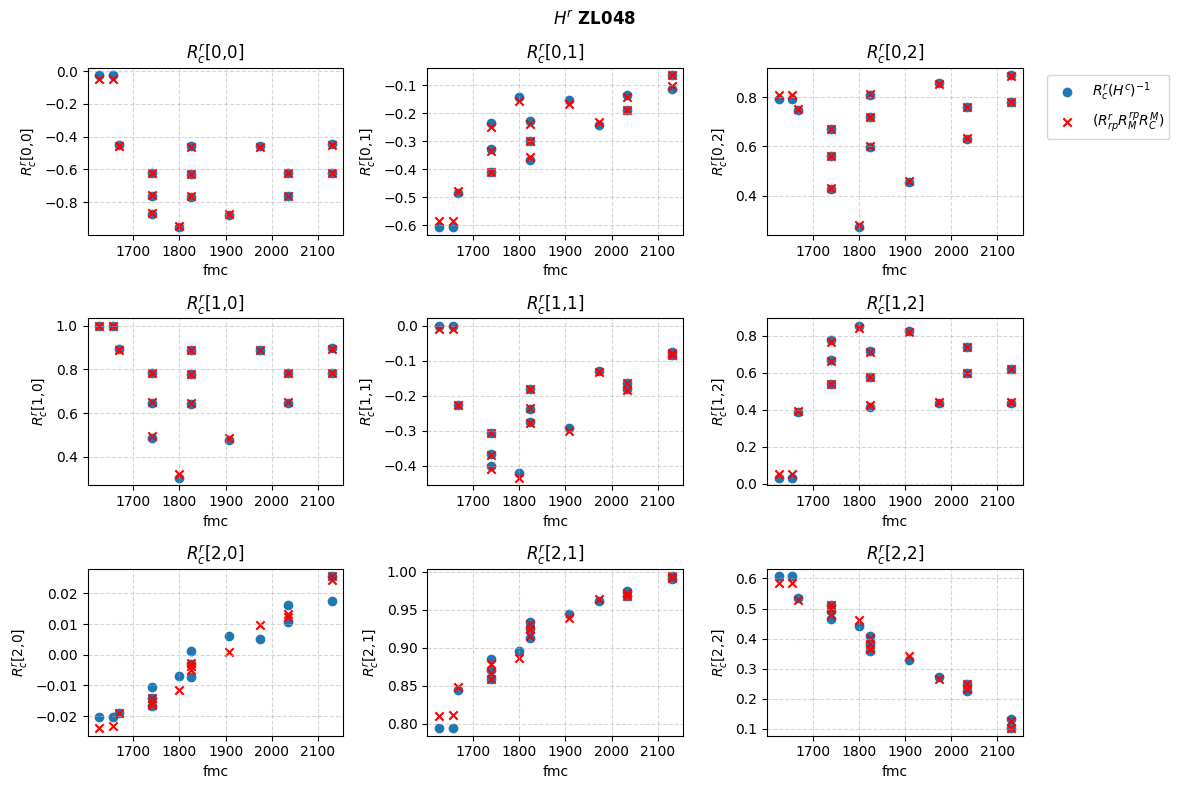

In [190]:
fig, ax = plot_R_rc( q_mc_zl_0, q_mc_zl_1, zl, "ZL048")

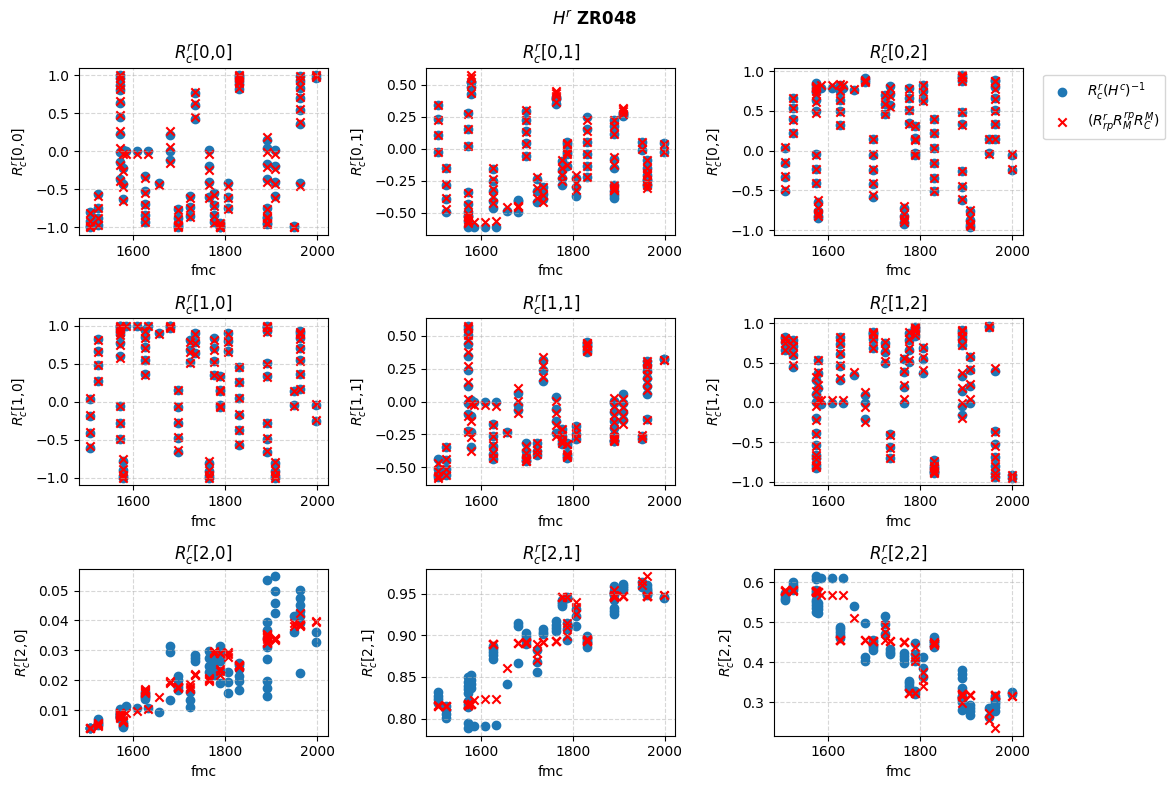

In [191]:
fig, ax = plot_R_rc( q_mc_zr_0, q_mc_zr_1, zr_filtered, "ZR048")

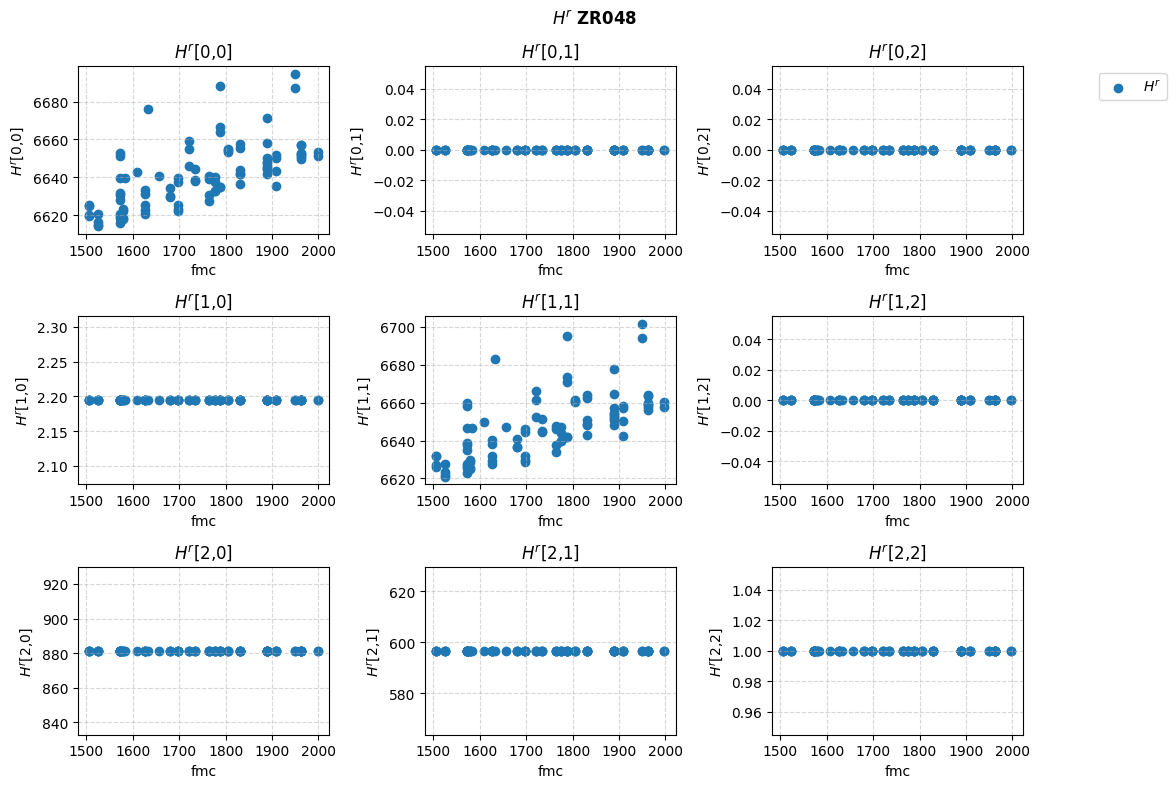

In [184]:
# plot HC
Hc_data = []

for i in range(data_.shape[0]):
  
  fl = data_["f_est"][i]
  b1,b2 = data_["b1_est"][i], data_["b2_est"][i]
  cx, cy = data_["cx_est"][i], data_["cy_est"][i]

  Hc = np.array([[fl+b1, b2, cx],
              [0,fl,cy],
              [0,0,1]]).T

  Hc_data.append(Hc)

# plot
fig, ax = plt.subplots(3, 3, figsize=(12,8))

for r in range(3):
  for c in range(3):

    ax[r,c].scatter(data_["fmc"], [H[r,c] for H in Hc_data], label="expectation")
    ax[r,c].set_title(f"$H^r$[{r},{c}]")
    ax[r,c].set_xlabel("fmc")
    ax[r,c].set_ylabel(f"$H^r$[{r},{c}]")
    ax[r,c].grid(linestyle="--", alpha=0.5)

ax[0,2].legend(["$H^r$", "$(R^r_{rp} R^{rp}_M R^M_C) H^c$"], bbox_to_anchor=(1.6,1))

fig.suptitle(f"$H^r$ {f_str}", fontweight="bold", fontsize=12)
fig.tight_layout()

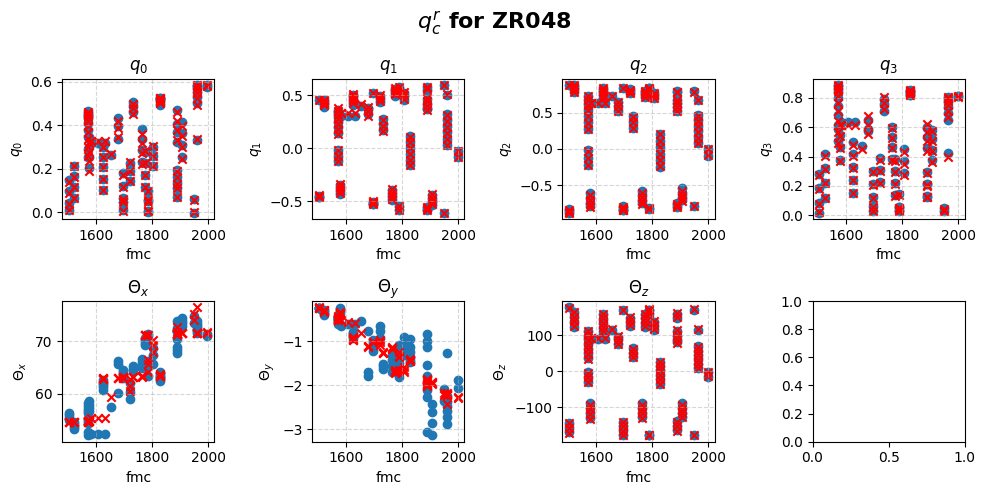

In [185]:
data_ = zr_filtered.copy()
f_str = "ZR048"

q_rc_data = []
q_rc_model = []
euler_rc_data = []
euler_rc_model = []
for i in range(data_.shape[0]):
  # from data
  H_r = get_H_r_data(i, data_)
  fl = data_["f_est"][i]
  b1, b2 = data_["b1_est"][i], data_["b2_est"][i]
  cx, cy = data_["cx_est"][i], data_["cy_est"][i]
  Hc_inv =  np.array([[1/(fl+b1), 0, 0],
              [-b2/(fl*(fl+b1)),1/fl,0],
              [((cy*b2)/(fl*(fl+b1)))-(cx/(fl+b1)),-cy/fl,1]])
  
  R_rc = H_r @ Hc_inv
  q_rc_data.append(R.from_matrix(R_rc).as_quat(canonical=True))
  euler_rc_data.append(R.from_matrix(R_rc).as_euler("xyz", degrees=True))

  # from model
  f = data_["fmc"][i]
  rot_mc_0 = R.from_quat(q_mc_zr_0)
  rot_mc_1 = R.from_quat(q_mc_zr_1)
  rot_mc_model = rot_mc_0 * (rot_mc_1 ** (f/1000))
  rot_rrp = R.from_quat([3.02010699e-04,-1.49266848e-03,-7.92022859e-03,9.58993160e-0])
  rot_rpm = R.from_matrix(get_R_rpm(i, data_))
  rot_rc_model = rot_rrp * rot_rpm * rot_mc_model

  q_rc_model.append(rot_rc_model.as_quat(canonical=True))
  euler_rc_model.append(rot_rc_model.as_euler("xyz", degrees=True))


fig, ax = plt.subplots(2, 4, figsize=(10, 5))

for i in range(4):
  ax[0,i].scatter(data_["fmc"], [q[i] for q in q_rc_data])
  ax[0,i].scatter(data_["fmc"], [q[i] for q in q_rc_model], color="red", marker='x')
  ax[0,i].set_title(f"$q_{i}$")
  ax[0,i].set_xlabel("fmc")
  ax[0,i].set_ylabel(f"$q_{i}$")
  ax[0,i].grid(linestyle="--", alpha=0.5)

for i, angle in enumerate(["x", "y", "z"]):
  ax[1,i].scatter(data_["fmc"], [angle[i] for angle in euler_rc_data])
  ax[1,i].scatter(data_["fmc"], [angle[i] for angle in euler_rc_model], color="red", marker='x')
  ax[1,i].set_title(f"$\Theta_{angle}$")
  ax[1,i].set_xlabel("fmc")
  ax[1,i].set_ylabel(f"$\Theta_{angle}$")
  ax[1,i].grid(linestyle="--", alpha=0.5)

fig.suptitle(f"$q^r_c$ for {f_str}", fontsize=16, fontweight="bold")
fig.tight_layout()  


In [186]:
def plot_H_r(q_mc_0:np.ndarray, q_mc_1:np.ndarray, data_:pd.DataFrame, f_str:str):
  H_r_data = []
  H_r_model = []

  for i in range(data_.shape[0]):
    # from data
    H_r = get_H_r_data(i, data_)
    H_r_data.append(H_r)

    # from model
    f = data_["fmc"][i]
    rot_mc_0 = R.from_quat(q_mc_0)
    rot_mc_1 = R.from_quat(q_mc_1)
    rot_mc_model = rot_mc_0 * (rot_mc_1 ** (f/1000))
    rot_rrp = R.from_quat([3.02010699e-04,-1.49266848e-03,-7.92022859e-03,9.58993160e-0])
    rot_rpm = R.from_matrix(get_R_rpm(i, data_))
    rot_rc_model = rot_rrp * rot_rpm * rot_mc_model

    fl = data_["f_est"][i]
    b1, b2 = data_["b1_est"][i], data_["b2_est"][i]
    cx, cy = data_["cx_est"][i], data_["cy_est"][i]
    Hc =  np.array([[fl+b1,0,0],
                        [b2,fl,0],
                        [cx, cy, 1]])
    
    H_r_model.append(rot_rc_model.as_matrix() @ Hc)

  # plot
  fig, ax = plt.subplots(3, 3, figsize=(12,8))

  for r in range(3):
    for c in range(3):

      ax[r,c].scatter(data_["fmc"], [H[r,c] for H in H_r_data], label="expectation")
      ax[r,c].scatter(data_["fmc"], [H[r, c] for H in H_r_model], color="red", marker='x', label="model")
      ax[r,c].set_title(f"$H^r$[{r},{c}]")
      ax[r,c].set_xlabel("fmc")
      ax[r,c].set_ylabel(f"$H^r$[{r},{c}]")
      ax[r,c].grid(linestyle="--", alpha=0.5)

  ax[0,2].legend(["$H^r (H^c)^{-1}$", "$(R^r_{rp} R^{rp}_M R^M_C)$"], bbox_to_anchor=(1.6,1))

  fig.suptitle(f"$H^r$ {f_str}", fontweight="bold", fontsize=12)
  fig.tight_layout()
  
  return fig, ax

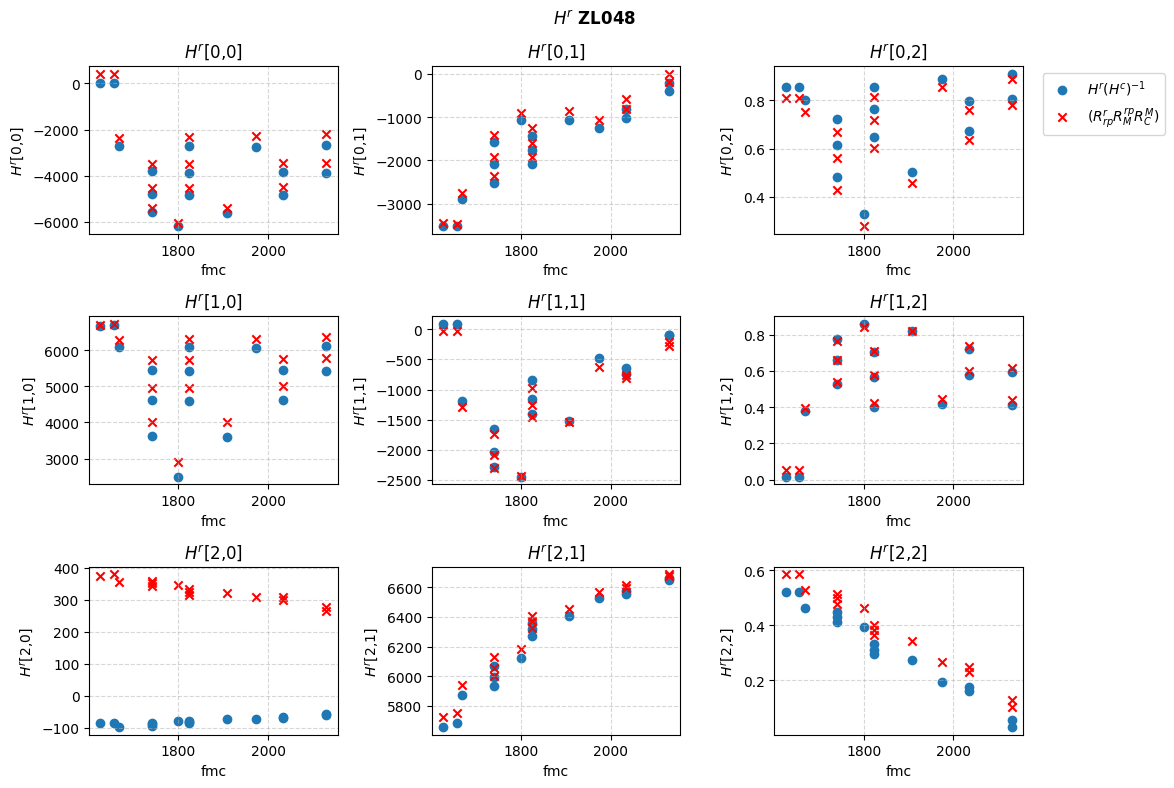

In [187]:
fig, ax = plot_H_r(q_mc_zl_0, q_mc_zl_1, zl, "ZL048")

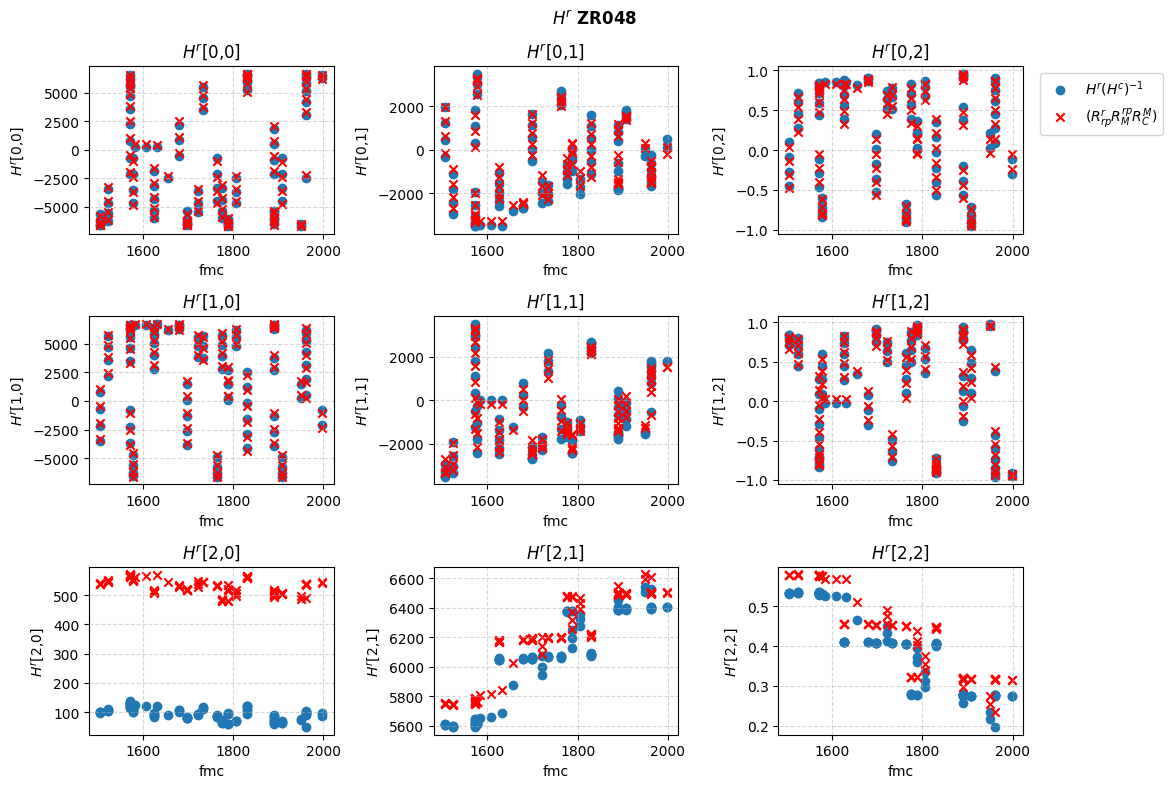

In [188]:
fig, ax = plot_H_r(q_mc_zr_0, q_mc_zr_1, zr_filtered, "ZR048")